In [2]:
import matplotlib.pyplot as plt
import seaborn as sns 
import pandas as pd 

In [37]:
df =  pd.read_csv('../data/processed/TelecomX-processed.csv', sep=',')
df

,ID_Cliente,Churn,Genero,Terceira_Idade,Parceiria,Dependentes,Tempo_Contrato_Meses,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Contrato,Fatura_Online,Metodo_Pagamento,Total_Servicos_Mensais,Cobrancas_Totais,Contas_Diarias
0,0002-ORFBO,0,Female,0,Yes,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.19
1,0003-MKNFE,0,Male,0,No,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,2.00
2,0004-TLHLJ,1,Male,0,No,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.46
3,0011-IGKFF,1,Male,1,Yes,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.27
4,0013-EXCHZ,1,Female,1,Yes,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,No,0,13,1,No,DSL,...,No,Yes,No,No,One year,No,Mailed check,55.15,742.90,1.84
7039,9992-RRAMN,1,Male,0,Yes,0,22,1,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70,2.84
7040,9992-UJOEL,0,Male,0,No,0,2,1,No,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,1.68
7041,9993-LHIEB,0,Male,0,Yes,1,67,1,No,DSL,...,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,2.26


Gráfico de distribuição da Evasão(Churn)

In [20]:
#calculo de contagem e porcentagem de evasao
churn_counts = df['Churn'].value_counts()
churn_porcentages = df['Churn'].value_counts(normalize=True)*100

churn_counts

Churn
0    5174
1    1869
Name: count, dtype: int64

C:\Users\biiel\AppData\Local\Temp\ipykernel_24000\360439684.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


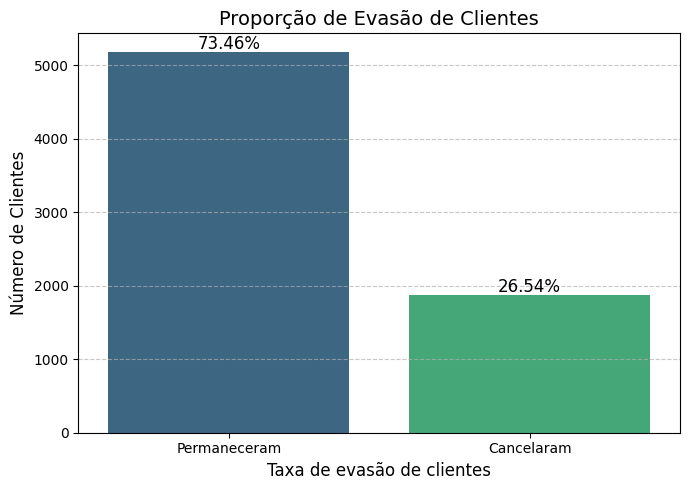

In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Proporção de Evasão de Clientes', fontsize=14)
plt.xlabel('Taxa de evasão de clientes', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.xticks([0, 1], ['Permaneceram', 'Cancelaram'], fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in churn_porcentages.items():
    plt.text(index, churn_counts[index]+ 50, f'{row:.2f}%', color='black', ha='center', fontsize=12 )
    
    plt.tight_layout()
    plt.show



Análise Descritiva


In [36]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols

['Churn',
 'Terceira_Idade',
 'Dependentes',
 'Tempo_Contrato_Meses',
 'Servico_Telefone',
 'Total_Servicos_Mensais',
 'Cobrancas_Totais',
 'Contas_Diarias']

In [38]:
descriptive_stats = df[numeric_cols].describe()
descriptive_stats

,Churn,Terceira_Idade,Dependentes,Tempo_Contrato_Meses,Servico_Telefone,Total_Servicos_Mensais,Cobrancas_Totais,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.299588,32.371149,0.903166,64.761692,2279.734304,2.158675
std,0.441561,0.368612,0.458110,24.559481,0.295752,30.090047,2266.794470,1.003088
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,35.500000,398.550000,1.180000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,70.350000,1394.550000,2.340000
75%,1.000000,0.000000,1.000000,55.000000,1.000000,89.850000,3786.600000,2.990000
max,1.000000,1.000000,1.000000,72.000000,1.000000,118.750000,8684.800000,3.960000


Contagem de Evasão por Variáveis Categóricas

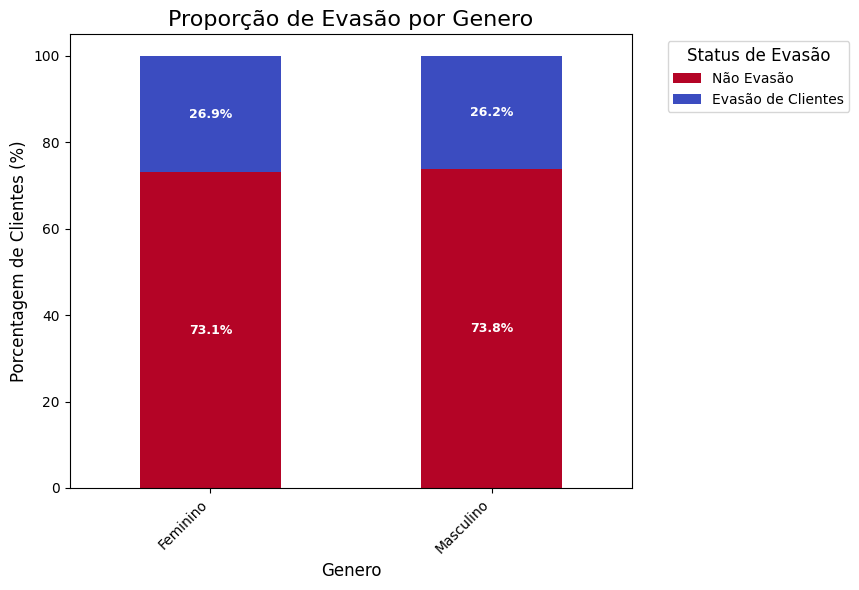

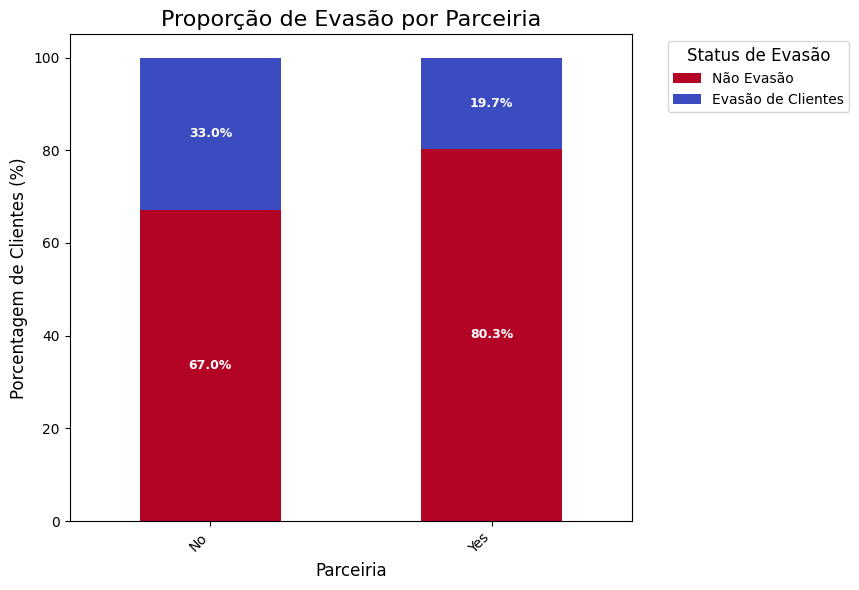

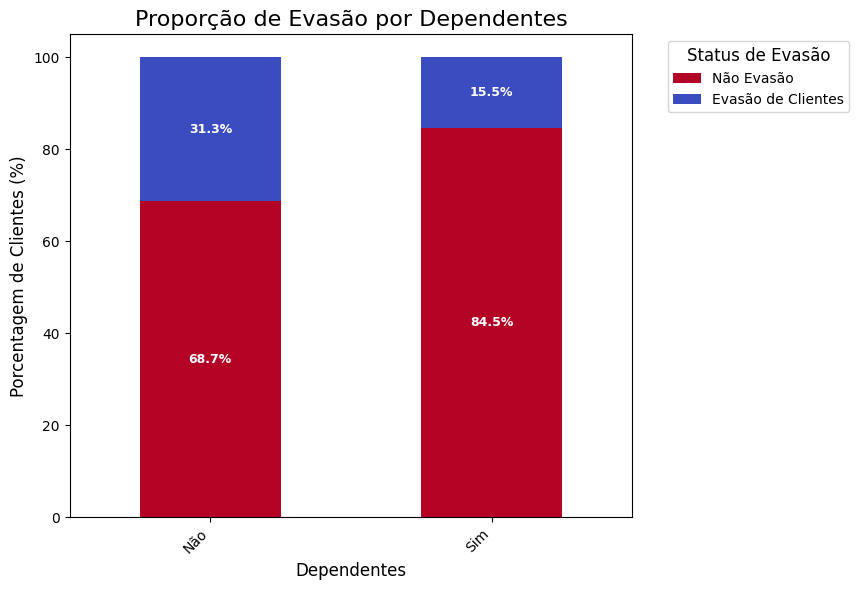

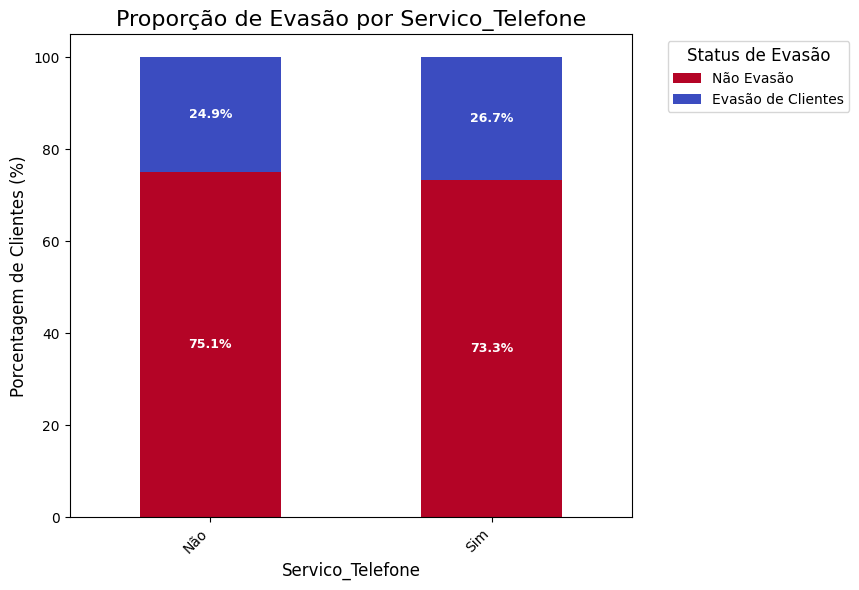

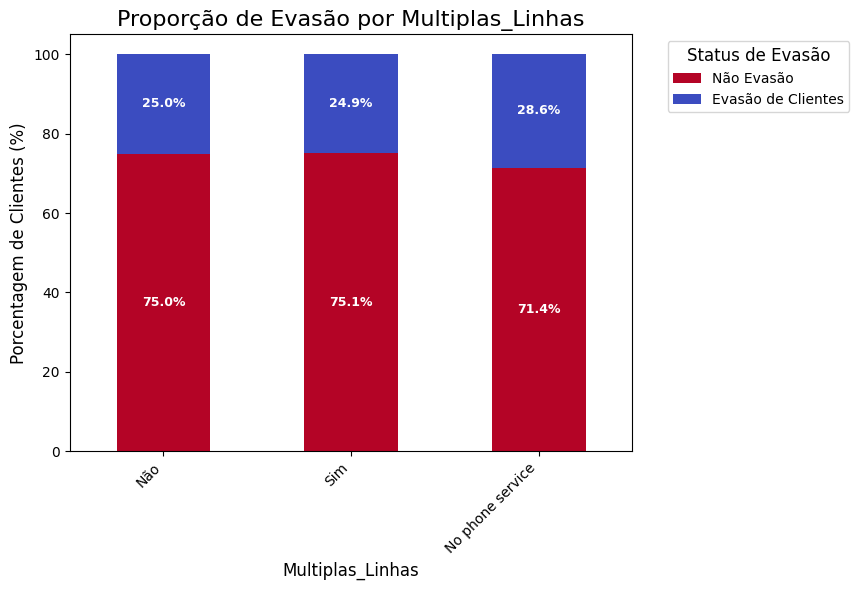

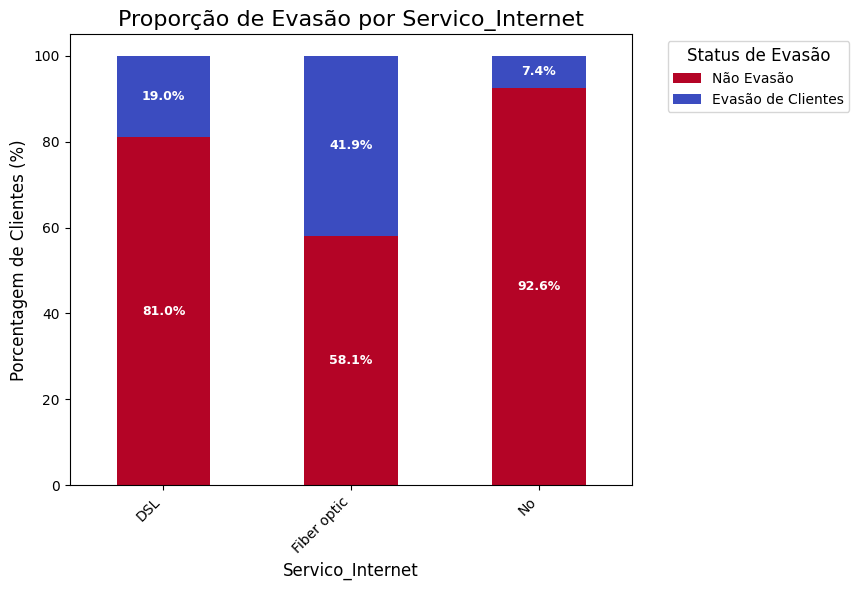

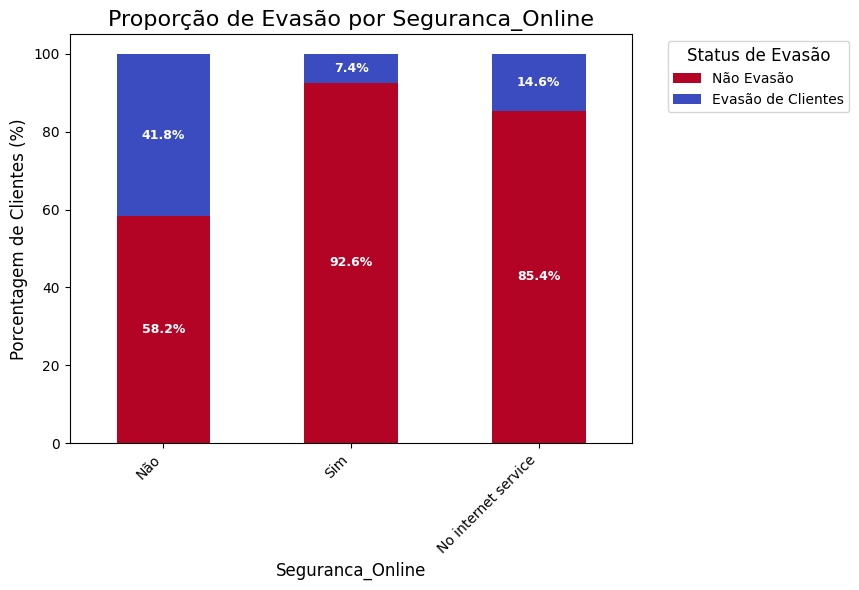

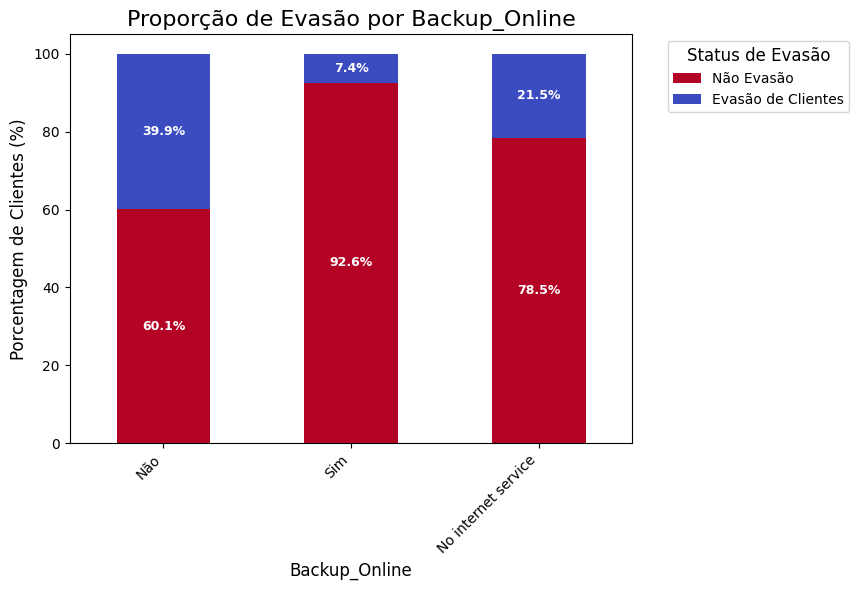

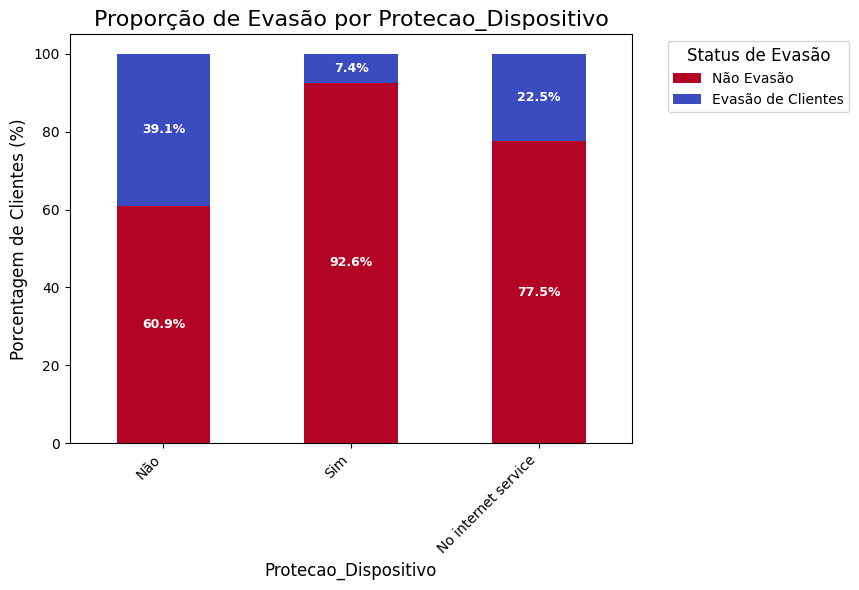

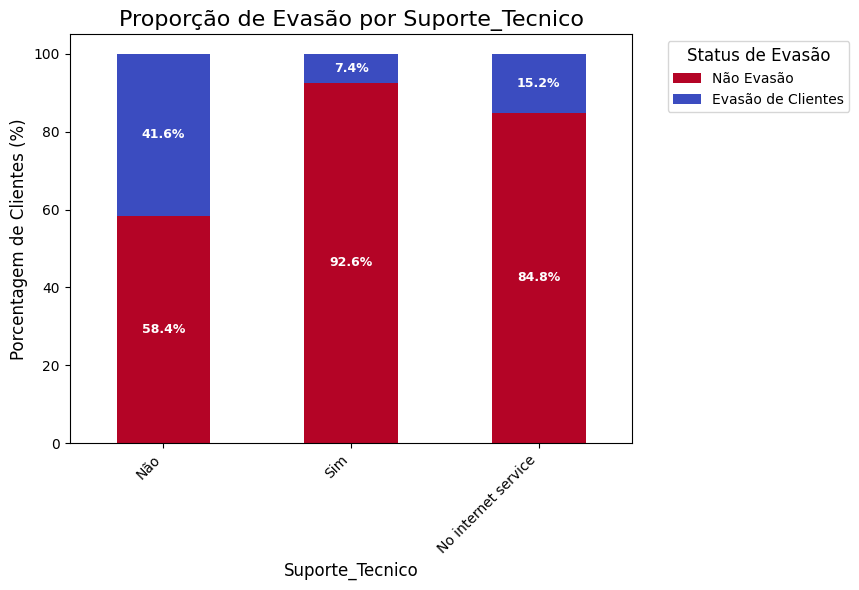

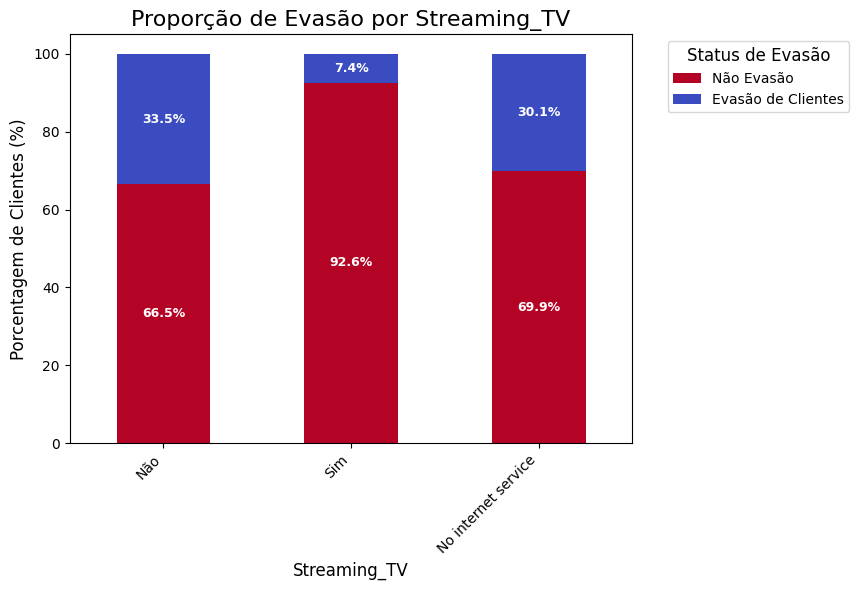

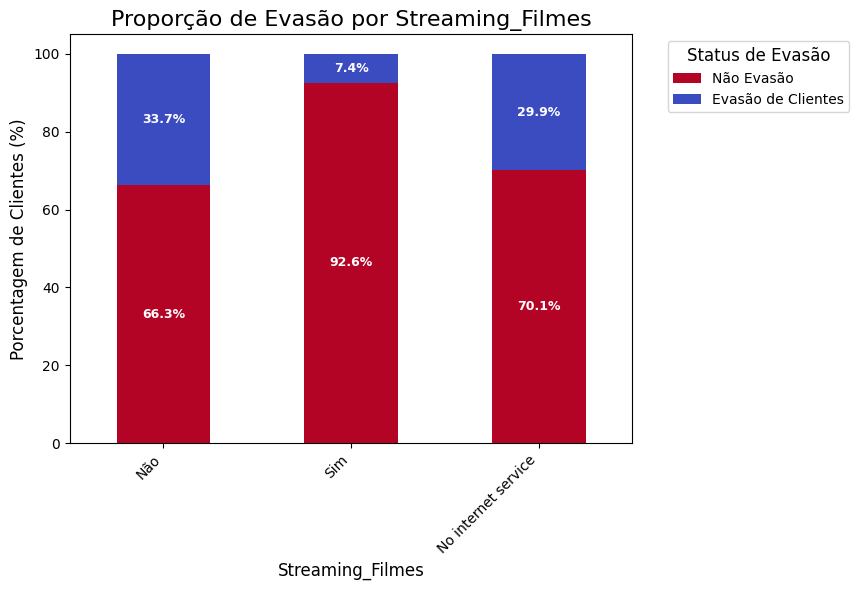

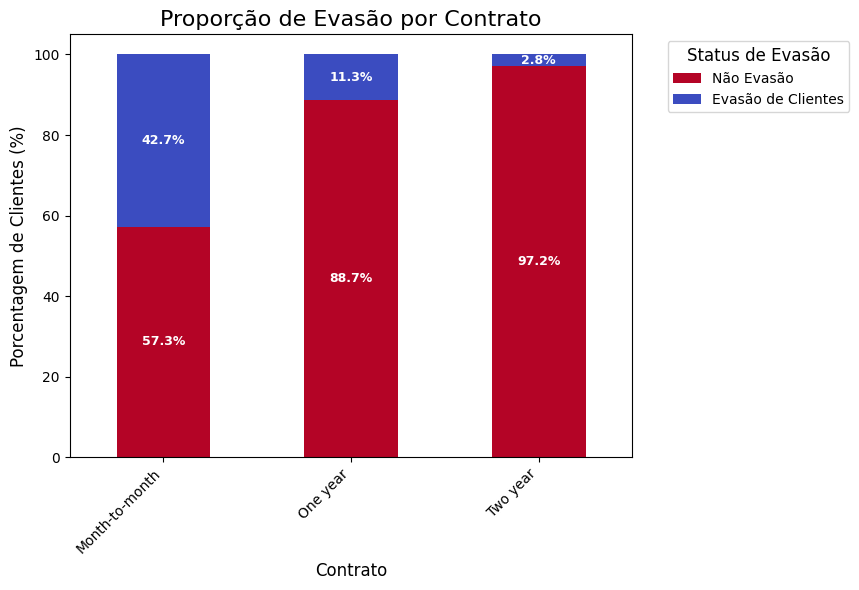

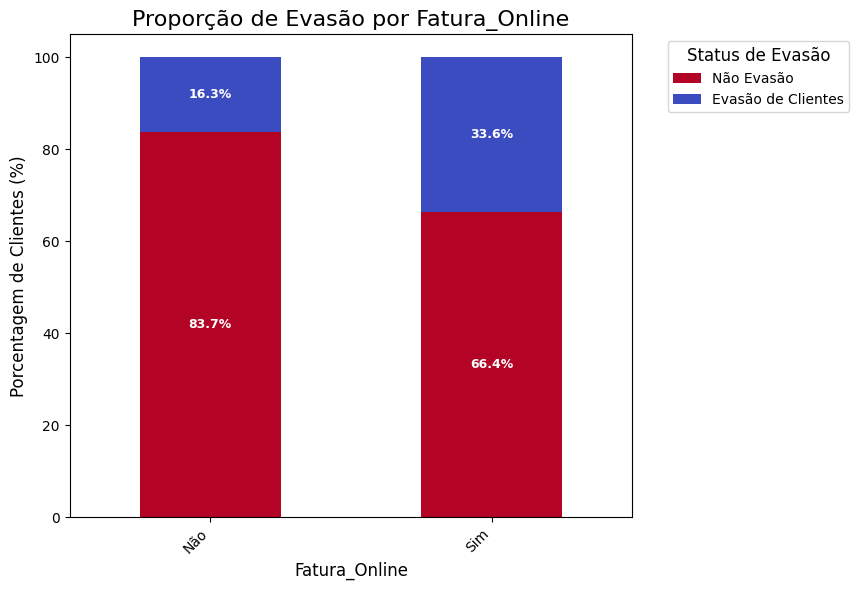

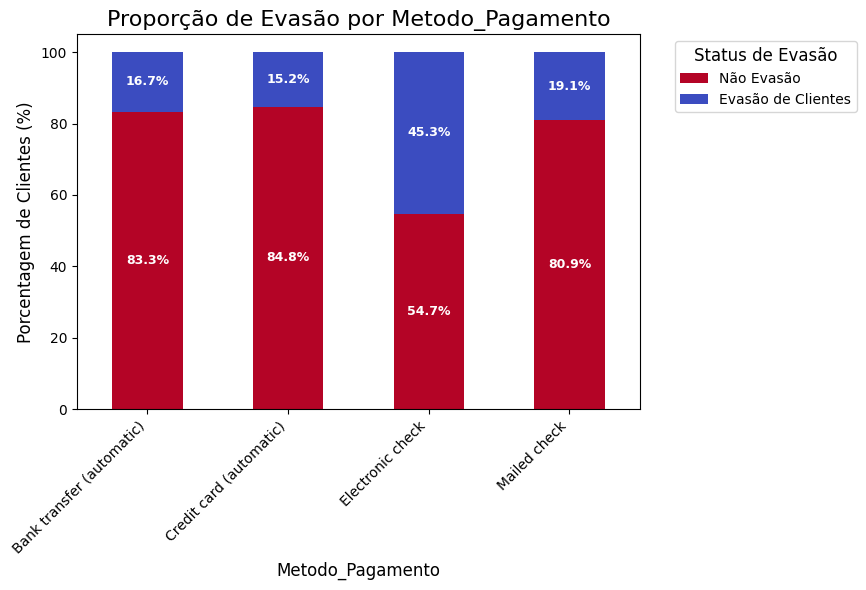

In [78]:
categorical_cols = [
    'Genero', 'Parceiria', 'Dependentes', 'Servico_Telefone',
    'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online',
    'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico',
    'Streaming_TV', 'Streaming_Filmes', 'Contrato',
    'Fatura_Online', 'Metodo_Pagamento'
]

label_mappings = {
    'Genero': {0: 'Feminino', 1: 'Masculino'}, # Assumindo 0 para Feminino, 1 para Masculino
    'Cidadao_Senior': {0: 'Não-Idoso', 1: 'Idoso'},
    'Parceiro': {0: 'Não', 1: 'Sim'},
    'Dependentes': {0: 'Não', 1: 'Sim'},
    'Servico_Telefone': {0: 'Não', 1: 'Sim'},
    'Multiplas_Linhas': {0: 'Não', 1: 'Sim',2:'No phone service'}, # Pode ter 'No phone service'
    'Seguranca_Online': {0: 'Não', 1: 'Sim', 2:'No internet service'}, # Pode ter 'No internet service'
    'Backup_Online': {0: 'Não', 1: 'Sim', 2:'No internet service'},    # Pode ter 'No internet service'
    'Protecao_Dispositivo': {0: 'Não', 1: 'Sim', 2:'No internet service'}, # Pode ter 'No internet service'
    'Suporte_Tecnico': {0: 'Não', 1: 'Sim', 2:'No internet service'},  # Pode ter 'No internet service'
    'Streaming_TV': {0: 'Não', 1: 'Sim', 2:'No internet service'},     # Pode ter 'No internet service'
    'Streaming_Filmes': {0: 'Não', 1: 'Sim', 2:'No internet service'}, # Pode ter 'No internet service'
    'Fatura_Online': {0: 'Não', 1: 'Sim', 2:'No internet service'}
}

# Loop para criar um gráfico de barras empilhadas de porcentagem para cada variável categórica
for col in categorical_cols:
    plt.figure(figsize=(10, 6))

    churn_by_category = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    churn_by_category = churn_by_category.rename(columns={0: 'Não Evasão', 1: 'Evasão de Clientes'})

    ax = churn_by_category.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm_r', ax=plt.gca())

    plt.title(f'Proporção de Evasão por {col}', fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Porcentagem de Clientes (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Status de Evasão', fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Aplicar os rótulos de 0/1 se a coluna estiver no dicionário de mapeamento
    if col in label_mappings:
        current_ticks = ax.get_xticks()
        mapped_labels = [label_mappings[col].get(int(t), t) for t in current_ticks]
        ax.set_xticklabels(mapped_labels)

    # --- Adicionar rótulos de porcentagem dentro das barras ---
    for container in ax.containers:
        # container é um Patch (barra) do matplotlib
        labels = [f'{w:.1f}%' if (w := v.get_height()) > 0 else '' for v in container] # Evita 0.0% para segmentos muito pequenos
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white', weight='bold') # Cor do texto

    plt.tight_layout(rect=[0, 0, 0.88, 1]) # Ajusta o layout para acomodar a legenda
    plt.show()

Contagem de evasão por variável numérica



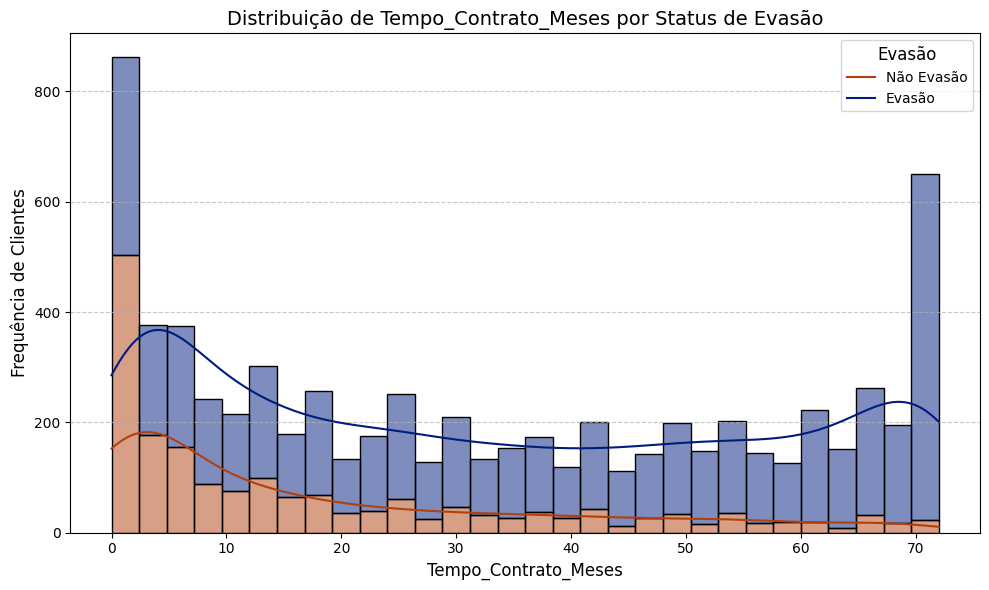

C:\Users\biiel\AppData\Local\Temp\ipykernel_24000\1578810596.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='dark')


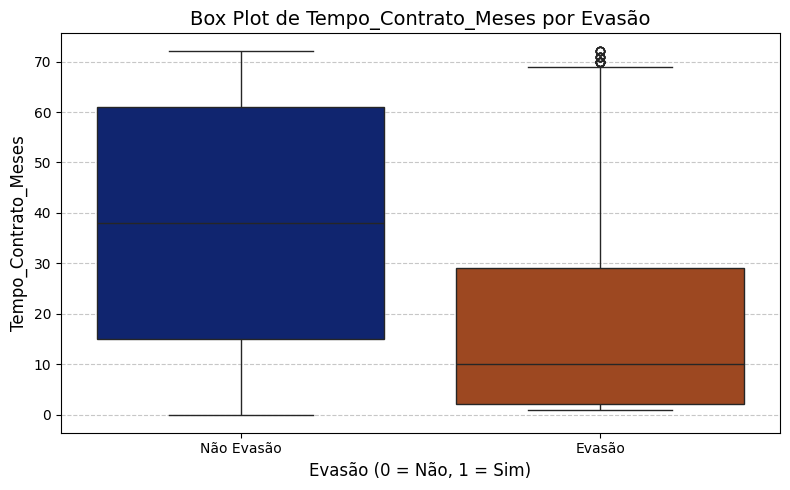

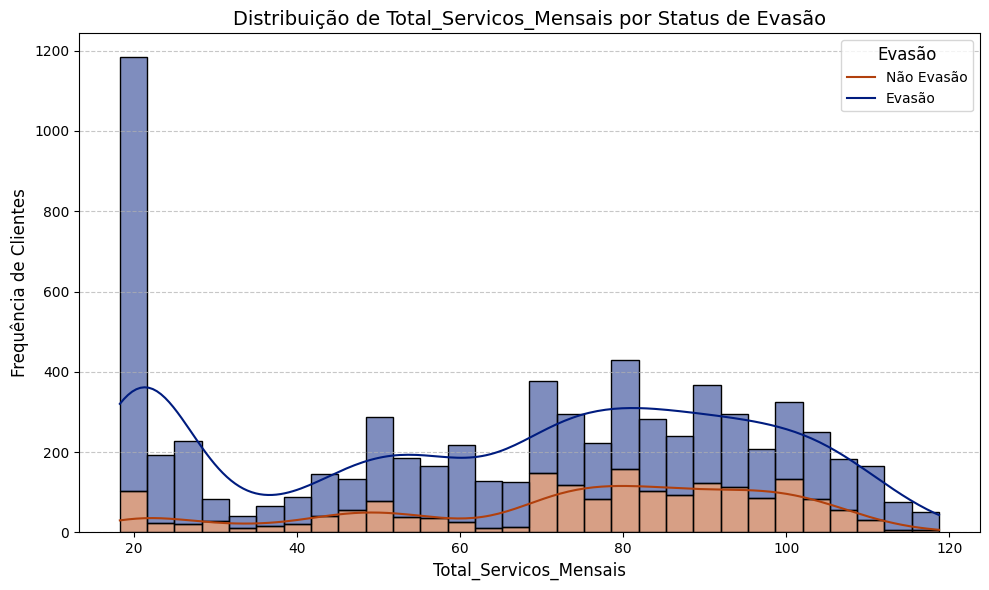

C:\Users\biiel\AppData\Local\Temp\ipykernel_24000\1578810596.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='dark')


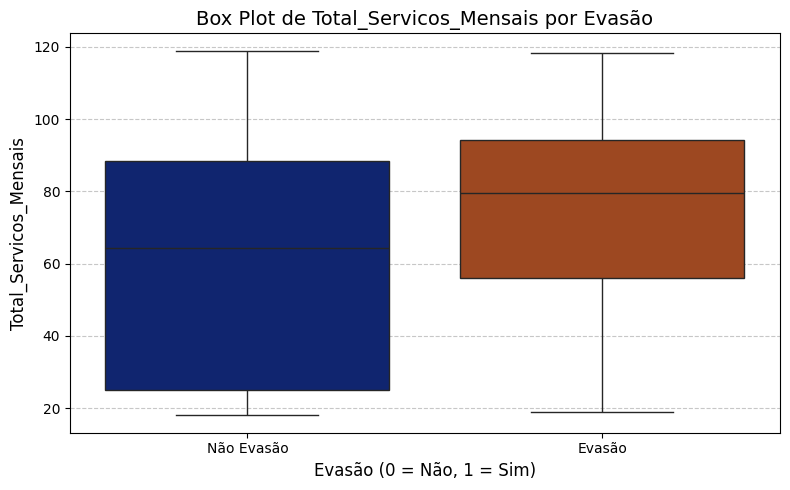

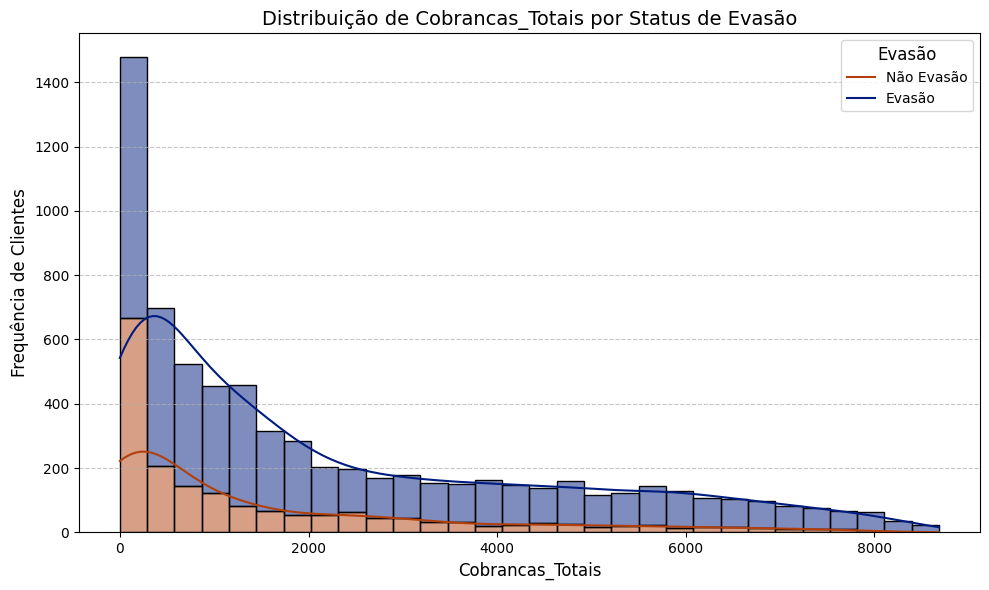

C:\Users\biiel\AppData\Local\Temp\ipykernel_24000\1578810596.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='dark')


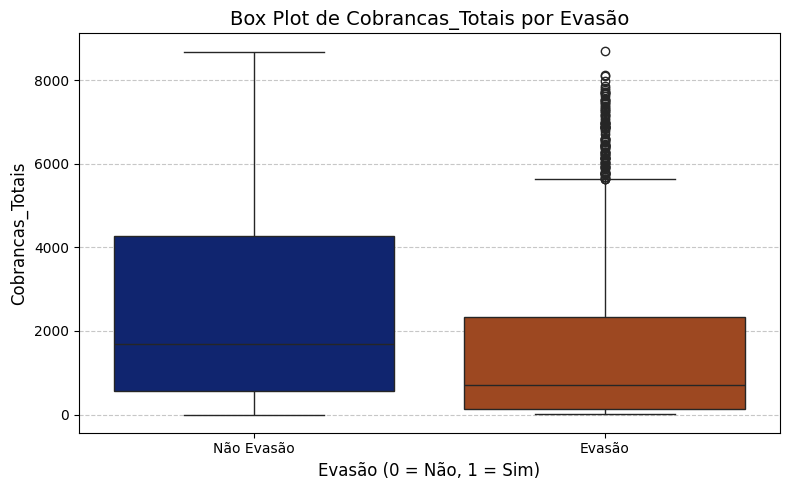

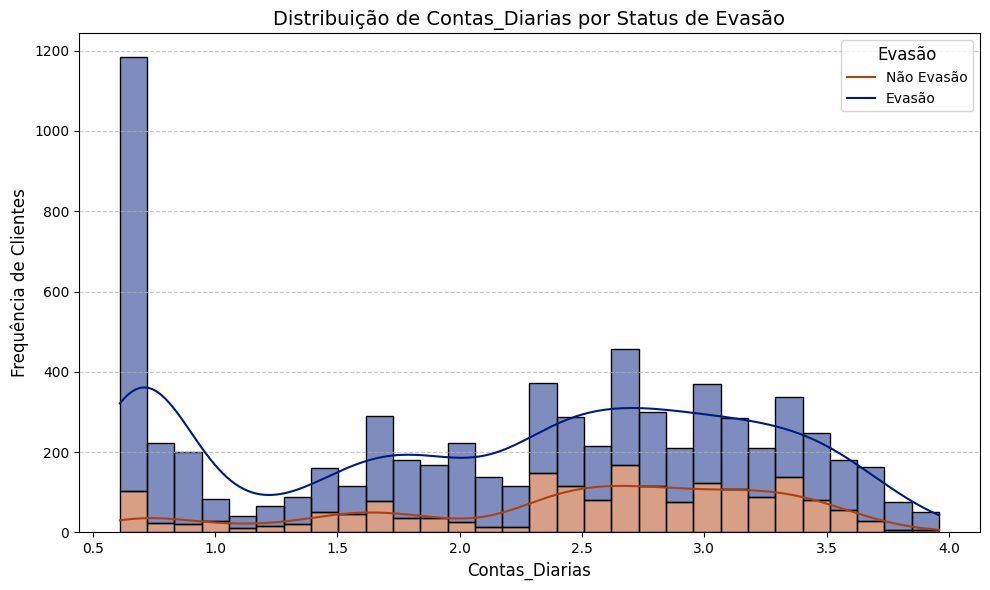

C:\Users\biiel\AppData\Local\Temp\ipykernel_24000\1578810596.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, palette='dark')


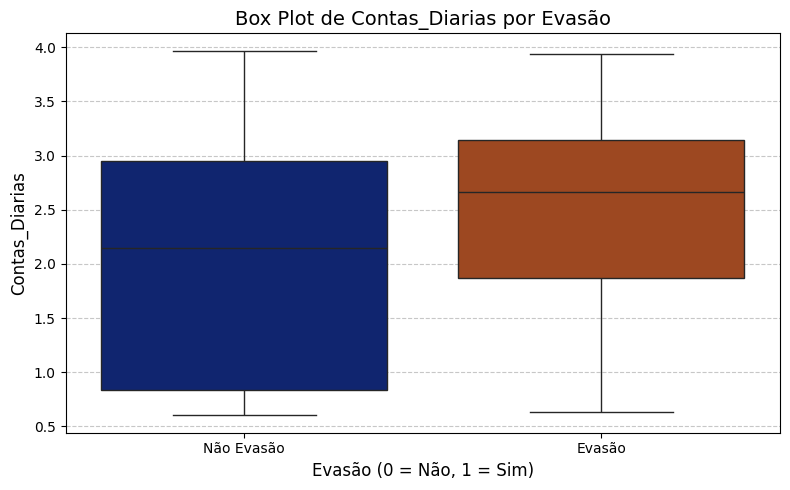

In [92]:
# Lista de variáveis numéricas para analisar em relação ao Churn
numerical_cols_for_churn_dist = [
    'Tempo_Contrato_Meses',
    'Total_Servicos_Mensais',
    'Cobrancas_Totais',
    'Contas_Diarias' # A nova coluna que criamos
]

# Loop para criar um gráfico de distribuição (histograma com KDE) para cada variável numérica
for col in numerical_cols_for_churn_dist:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, hue='Churn', multiple='stack', kde=True, stat='count', palette='dark', bins=30)
    plt.title(f'Distribuição de {col} por Status de Evasão', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frequência de Clientes', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title='Evasão', labels=['Não Evasão', 'Evasão'], fontsize=10, title_fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Opcional: Box plot para uma visão mais compacta da distribuição e outliers
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y=col, data=df, palette='dark')
    plt.title(f'Box Plot de {col} por Evasão', fontsize=14)
    plt.xlabel('Evasão (0 = Não, 1 = Sim)', fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks([0, 1], ['Não Evasão', 'Evasão'], fontsize=10)
    plt.yticks(fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
